In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
import io
import astropy.io.fits
import src.downloadCutout as downloadCutout
import src.downloadPsf as downloadPsf

from astropy.visualization import simple_norm
from astropy.modeling.models import Sersic2D
from astropy.convolution import convolve, Gaussian2DKernel
from photutils.segmentation import detect_threshold, detect_sources
import time
import statmorph

In [2]:
ra_center, dec_center =208.72415161132812, -0.9389227032661438
user = 'hyp0515'
password = 'PHFrCTavyczTCw/onxRGH537qhiLWqYSRuHB6WHE'
filter = 'HSC-R'

In [3]:
rect = downloadCutout.Rect.create(
    ra=	ra_center,
    dec=dec_center,
    sw="10arcsec",
    sh="10arcsec",
    variance=True,
    mask=True,
    filter=filter,
)

images = downloadCutout.download(rect, user=user, password=password)
_, image_data = images[0]
image_hdu = astropy.io.fits.open(io.BytesIO(image_data))
image_hdu.info()
image = image_hdu[1].data
mask  = image_hdu[2].data
print(np.max(mask), np.min(mask))
print(mask[mask.shape[0]//2, mask.shape[1]//2])
var   = image_hdu[3].data

psfreq = downloadPsf.PsfRequest.create(
    ra=ra_center,
    dec=dec_center,
    filter=filter
)
psfs = downloadPsf.download(psfreq, user=user, password=password)
print(psfs)
_, psf_data = psfs[0]
psf_hdu = astropy.io.fits.open(io.BytesIO(psf_data))
psf_hdu.info()
psf = psf_hdu[0].data


Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      27   ()      
  1                1 ImageHDU        44   (120, 120)   float32   
  2                1 ImageHDU        60   (120, 120)   int32   
  3                1 ImageHDU        44   (120, 120)   float32   
106528 0
32
[({'lineno': 0, 'rerun': 'pdr3_wide', 'filter': 'HSC-R', 'tract': 9367, 'type': 'coadd', 'patch': (5, 3), 'psfreq': PsfRequest(rerun='pdr3_wide', type='coadd', filter='HSC-R', tract=9367, patch=(5, 3), ra=208.72415161132812, dec=-0.9389227032661438, centered=True, name='{lineno}_psf_{type}_{ra:.5f}_{dec:+.5f}_{tract}_{patch[0]},{patch[1]}_{filter}', lineno=0)}, b'SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                  -64 / number of bits per data pixel                  NAXIS   =                    2 / number of data axes                            NAXIS1  =                   43 / length o

28849.93305294745


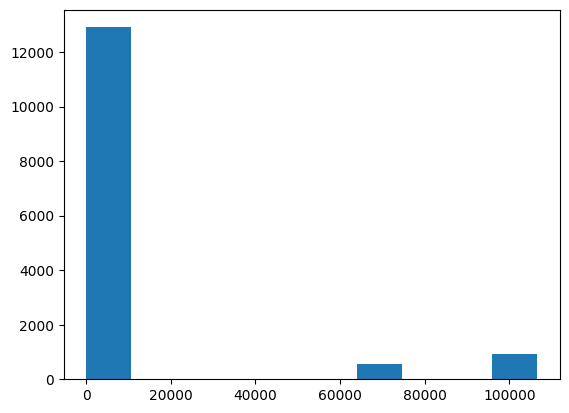

In [4]:
print(np.std(mask.flatten()))
plt.hist(mask.flatten())
plt.show()

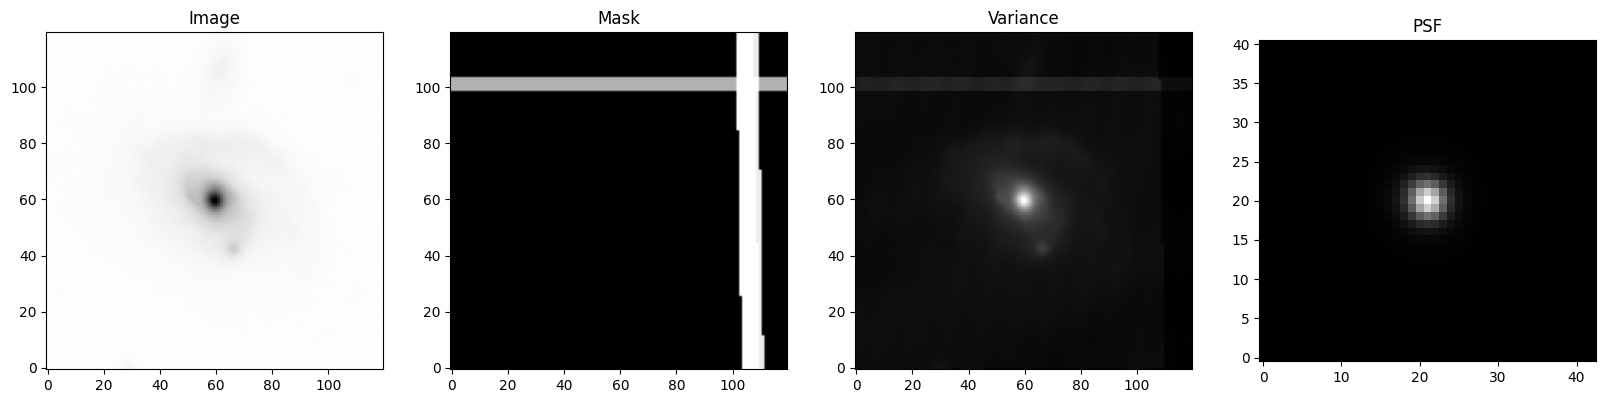

In [5]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(image, cmap="gray_r", origin="lower")
ax[0].set_title("Image")
ax[1].imshow(mask, cmap="gray", origin="lower")
ax[1].set_title("Mask")
ax[2].imshow(var, cmap="gray", origin="lower")
ax[2].set_title("Variance")
ax[3].imshow(psf, cmap="gray", origin="lower")
ax[3].set_title("PSF")
plt.show()

In [6]:
threshold = detect_threshold(image, 10,)
npixels = 200  # minimum number of connected pixels
segmap = detect_sources(image, threshold, npixels)
segmap = np.array(segmap)
segmap = np.where(segmap != segmap[int(segmap.shape[0]/2), int(segmap.shape[1]/2)], 0, 1)
print(segmap.shape)

(120, 120)


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_54001/2459929732.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  segmap = np.array(segmap)


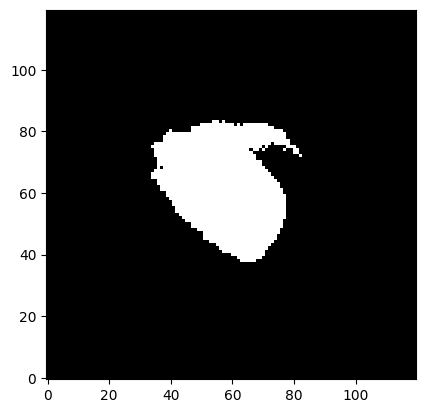

In [7]:
plt.imshow(segmap, cmap='gray', origin='lower')
plt.show()

In [8]:
new_mask = np.zeros_like(mask)
new_mask[segmap == 1] = 0
new_mask[segmap == 0] = np.where((mask[segmap == 0]>=np.min(mask[segmap == 0])+np.std(mask.flatten()))|(image[segmap == 0]>=np.max(image[segmap == 1])*2/3), 1, 0)
mask = new_mask.astype(bool)

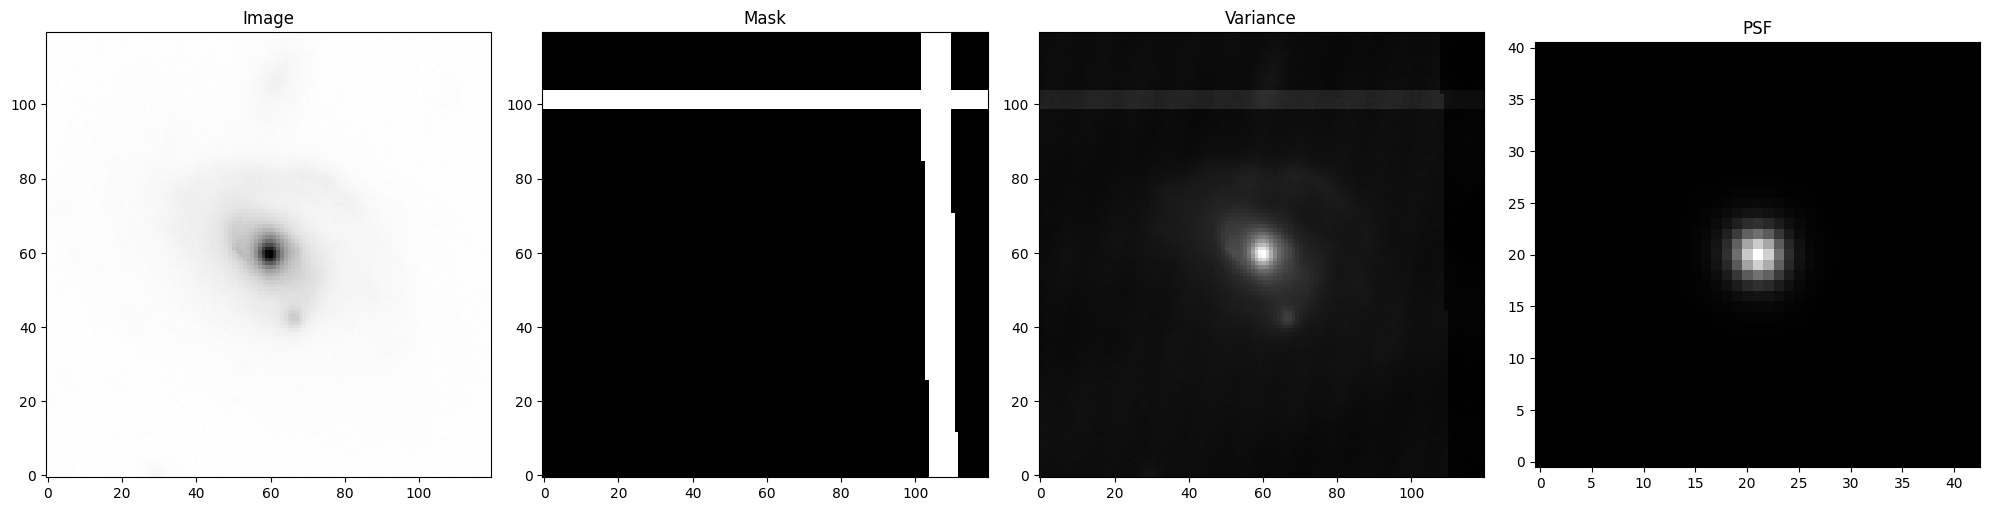

In [9]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(image, cmap="gray_r", origin="lower")
ax[0].set_title("Image")
ax[1].imshow(mask, cmap="gray", origin="lower")
ax[1].set_title("Mask")
ax[2].imshow(var, cmap="gray", origin="lower")
ax[2].set_title("Variance")
ax[3].imshow(psf, cmap="gray", origin="lower")
ax[3].set_title("PSF")
plt.tight_layout()
plt.savefig('./figures/progress_apr/hsc_cutout.png')
plt.show()

In [10]:
start = time.time()
source_morphs = statmorph.source_morphology(image=image, segmap=segmap, psf=psf, weightmap=np.sqrt(var), mask=mask, eta=0.15)
print('Time: %g s.' % (time.time() - start))

Time: 0.511371 s.


In [11]:
morph = source_morphs[0]

In [12]:
print('BASIC MEASUREMENTS (NON-PARAMETRIC)')
print('Gini =', morph.gini)
print('M20 =', morph.m20)
print('F(G, M20) =', morph.gini_m20_bulge)
print('S(G, M20) =', morph.gini_m20_merger)
print('C =', morph.concentration)
print('A =', morph.asymmetry)
print('S =', morph.smoothness)
print('A_s =', morph.shape_asymmetry)
print()
print('SERSIC MODEL')
print('sersic_amplitude =', morph.sersic_amplitude)
print('sersic_rhalf =', morph.sersic_rhalf)
print('sersic_n =', morph.sersic_n)
print('sersic_xc =', morph.sersic_xc)
print('sersic_yc =', morph.sersic_yc)
print('sersic_ellip =', morph.sersic_ellip)
print('sersic_theta =', morph.sersic_theta)
print('sersic_chi2_dof =', morph.sersic_chi2_dof)

BASIC MEASUREMENTS (NON-PARAMETRIC)
Gini = 0.5960430550674262
M20 = -2.1074007645776587
F(G, M20) = 0.4508418524360769
S(G, M20) = -0.02984608175954273
C = 3.4210406403679805
A = 0.1623444211867983
S = 0.013443390003327846
A_s = 0.20225991823312636

SERSIC MODEL
sersic_amplitude = 1.1337336584456492
sersic_rhalf = 25.184535609437205
sersic_n = 3.085116100733837
sersic_xc = 59.588891160808515
sersic_yc = 59.80648674441577
sersic_ellip = 0.295259041489718
sersic_theta = 2.40414785794403
sersic_chi2_dof = 17.519477188863686


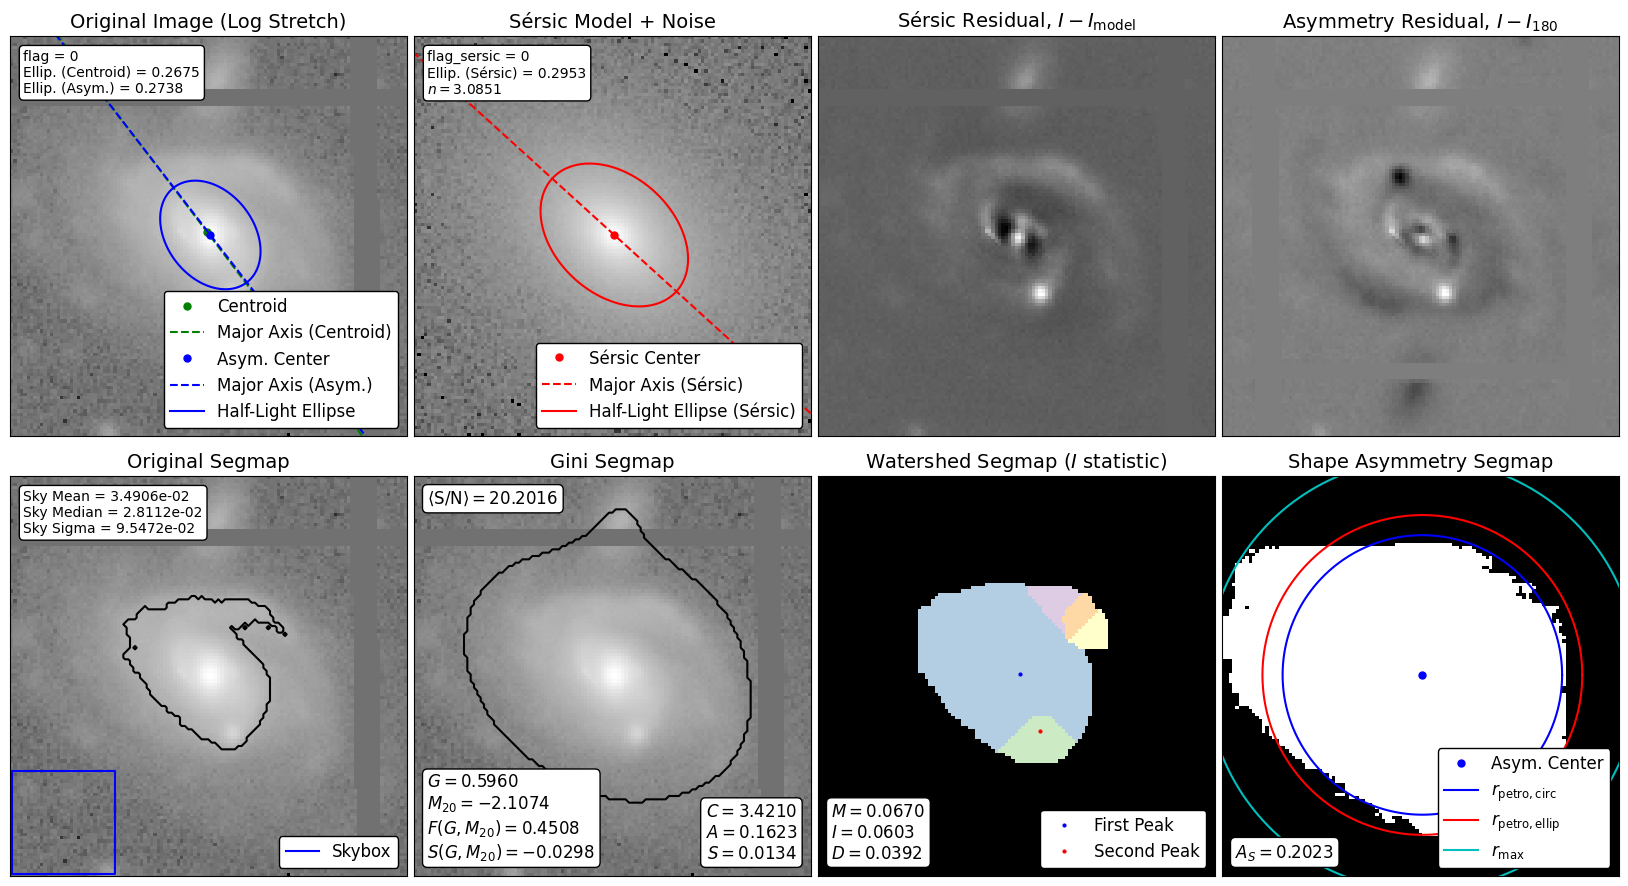

In [13]:
from statmorph.utils.image_diagnostics import make_figure
fig = make_figure(morph)
fig.savefig('./figures/progress_apr/statmorph.png')

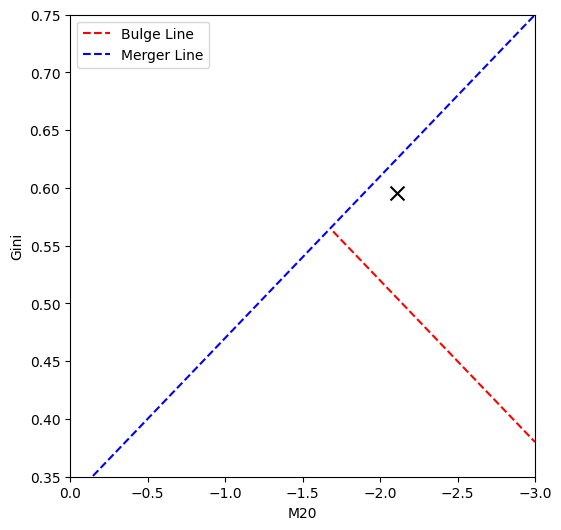

In [14]:
x = np.linspace(0, -3, 100)
merger_line = -0.14 * x + 0.33
bulge_line = 0.14 * x + 0.8
plt.figure(figsize=(6, 6))
plt.scatter(morph.m20, morph.gini, s=100, color='k', marker='x')
plt.plot(x[bulge_line<merger_line], bulge_line[bulge_line<merger_line], color='red', linestyle='--', label='Bulge Line')
plt.plot(x, merger_line, color='blue', linestyle='--', label='Merger Line')
plt.xlim((0, -3))
plt.ylim((0.35, 0.75))
plt.xlabel('M20')
plt.ylabel('Gini')
plt.legend()
plt.show()

In [15]:
print(-0.693*morph.m20 + 4.95*morph.gini -3.96)
print(0.139*morph.m20 + 0.990*morph.gini -0.327)

0.4508418524360769
-0.02984608175954273
